In [ ]:
# Reinstall the specific versions Colab requires to stop the errors
!pip install pandas==2.2.2 numpy==1.26.4
!pip install SimpleITK

# IMPORTANT: Once this finishes, go to the top menu:
# Runtime -> Restart Session

  Using cached simpleitk-2.5.3-cp311-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (7.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 45.6 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path

master =  pd.read_csv('/content/drive/Shareddrives/CSC550/Project_Final_Flattened_Dataset.csv')

In [ ]:
# This is how the Flattened Dataset was created, but does not need to be run
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path

# GOOGLE DRIVE PATHS
# CSV Path
# csv_path = '/content/drive/Shareddrives/CSC550/Final_Flattened_Dataset/Raw_CSVs/'
# MRI Images Path
# mri_path = '/content/drive/Shareddrives/CSC550/Final_Flattened_Dataset/my_mri_data/'

csv_path = '/content/drive/MyDrive/Raw_CSVs'
mri_path = '/content/drive/MyDrive/All_MRIs_2018'


#LOAD DATA
#braak = pd.read_csv(os.path.join(csv_path, 'OASIS3_AV1451_braak_tauopathy.csv'))
cog = pd.read_csv(os.path.join(csv_path, 'OASIS3_UDSc1_cognitive_assessments.csv'))
cdr = pd.read_csv(os.path.join(csv_path, 'OASIS3_UDSb4_cdr.csv'))
fs = pd.read_csv(os.path.join(csv_path, 'OASIS3_Freesurfer_output.csv'))
demo = pd.read_csv(os.path.join(csv_path, 'OASIS3_demographics.csv'))
#mr_json = pd.read_csv(os.path.join(csv_path, 'OASIS3_MR_json.csv'))

# PRE-PROCESS VOLUMES
  # Calculate Normalized volumes (Standardizing for head size)
fs['Norm_Hippo'] = (fs['Left-Hippocampus_volume'] + fs['Right-Hippocampus_volume']) / fs['IntraCranialVol']
fs['Norm_Entorhinal'] = (fs['lh_entorhinal_volume'] + fs['rh_entorhinal_volume']) / fs['IntraCranialVol']
fs['days_mri'] = fs['MR_session'].str.extract(r'_d(\d+)').astype(float)
master = fs[['Subject', 'MR_session', 'days_mri', 'Norm_Hippo', 'Norm_Entorhinal']].copy()

# MATCHING LOOP (MoCA and CDR)
def get_closest_clinical_score(subject, mri_day, clinical_df, column):
  p_data = clinical_df[clinical_df['OASISID'] == subject].copy()
  if p_data.empty:
    return np.nan
  p_data['diff'] = (p_data['days_to_visit'] - mri_day).abs()
  best = p_data.sort_values('diff').iloc[0]
  if best['diff'] <= 365:
    return best[column]
  return np.nan

# Add results back to master
master['moca'] = master.apply(lambda row: get_closest_clinical_score(row['Subject'], row['days_mri'], cog, 'mocatots'),axis=1)
master['cdr'] = master.apply(lambda row: get_closest_clinical_score(row['Subject'], row['days_mri'], cdr, 'CDRTOT'), axis=1)
master['cdrsum'] = master.apply(lambda row: get_closest_clinical_score(row['Subject'], row['days_mri'], cdr, 'CDRSUM'), axis=1)

# 4-stage labeling
def map_to_4_stage(cdr_val):
  if cdr_val == 0:
    return 'Normal'
  elif cdr_val == 0.5:
    return 'Very Mild'
  elif cdr_val == 1.0:
    return 'Mild'
  elif cdr_val >= 2.0:
    return 'Moderate'
  else:
    return 'Exclude'

master['Group'] = master['cdr'].apply(map_to_4_stage)
master = master[master['Group'] != 'Exclude'].copy()

# MERGE DEMOGRPHICS & FILENAMES
demo_clean = demo.rename(columns={'OASISID': 'Subject'})
master = pd.merge(master, demo_clean[['Subject', 'GENDER', 'EDUC', 'APOE', 'AgeatEntry', "momdem", 'daddem']], on='Subject', how='left')

# FILL MISSING DATA OF MRI IMAGES
def fill_moca(row):
  if pd.isna(row['moca']):
    if row['cdr'] == 0: return 28.0
    if row['cdr'] == 0.5: return 22.0
    return 15.0
  return row['moca']

master['moca'] = master.apply(fill_moca, axis=1)
master['APOE'] = master['APOE'].fillna(33.0)
master['EDUC'] = master['EDUC'].fillna(master['EDUC'].median())
master['momdem'] = master['momdem'].fillna(0)
master['daddem'] = master['daddem'].fillna(0)

  # Flattening categories
master = pd.get_dummies(master, columns=['GENDER', 'APOE'], prefix=["Sex", 'APOE'])
boolean_columns = master.select_dtypes(include=['bool']).columns
master[boolean_columns] = master[boolean_columns].astype(int)

  # Flattening ranges
scaler = MinMaxScaler()
scale_columns = ['AgeatEntry', 'EDUC', 'Norm_Hippo', 'Norm_Entorhinal']
master[scale_columns] = scaler.fit_transform(master[scale_columns])

# FILTER BY ACTUAL FILES IN DRIVE
available_folders = os.listdir(mri_path)
master = master[master['MR_session'].isin(available_folders)].copy()
print(len(master))


# Find the .nii.gz inside each folder
def find_the_brain(row):
    session_dir = os.path.join(mri_path, row['MR_session'])
    session_dir_path = Path(session_dir)

    # The subdir for each sample either has one scan
    # result or more subdirs for each scan performed
    # in the same session. In this case, we will choose
    # the last scan
    subdirs = [p for p in session_dir_path.iterdir() if p.is_dir()]
    if (len(subdirs) == 0):
        return str(next(session_dir_path.glob('*.nii.gz')))

    subdirs = sorted(subdirs)
    for subdir in reversed(subdirs):
        scan_path = next(subdirs[-1].glob('*.nii.gz'), None)
        if (scan_path is not None):
            return str(scan_path)

    return None

master['image_path'] = master.apply(find_the_brain, axis=1)
master = master.dropna(subset=['image_path'])

print(len(master))

# 6. SAVE
master.to_csv('Project_Final_Flattened_Dataset.csv', index=False)

1933
1933


In [ ]:
import SimpleITK as sitk
import torch
from torch.utils.data import Dataset, Subset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split

class OasisDataset(Dataset):
    def __init__(self, mri_paths, clinical_data, labels):
        self.mri_paths = mri_paths
        self.clinical_data = torch.tensor(clinical_data, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.target_shape = (224, 224, 224)

    def __len__(self):
        return len(self.mri_paths)

    def __getitem__(self, idx):
        sitk_img = sitk.ReadImage(self.mri_paths[idx])

        # Calculate the required spacing to reach exactly 224x224x224
        # Target Spacing = (Original Size * Original Spacing) / Target Size
        orig_size = np.array(sitk_img.GetSize())
        orig_spacing = np.array(sitk_img.GetSpacing())
        target_spacing = (orig_size * orig_spacing) / np.array(self.target_shape)

        # Use resampler to get target_shape
        # while retaining physical size of
        # image
        resampler = sitk.ResampleImageFilter()
        resampler.SetSize(self.target_shape)
        resampler.SetOutputSpacing(target_spacing.tolist())
        resampler.SetOutputOrigin(sitk_img.GetOrigin())
        resampler.SetOutputDirection(sitk_img.GetDirection())
        resampler.SetInterpolator(sitk.sitkLinear)
        sitk_img = resampler.Execute(sitk_img)

        img_array = sitk.GetArrayFromImage(sitk_img)
        img_tensor = torch.from_numpy(img_array).float()

        # Unsqueeze to go from (D, H, W) to (1, D, H, W)
        img_tensor = img_tensor.unsqueeze(0)

        return img_tensor, self.clinical_data[idx], self.labels[idx]


In [ ]:
full_dataset = OasisDataset(
    master['image_path'].values,
    master[
        [col for col in master.columns if col.startswith('APOE')] +
        ['EDUC', 'momdem', 'daddem', 'AgeatEntry', 'Norm_Hippo', 'Norm_Entorhinal'] +
        [col for col in master.columns if col.startswith('Sex')]
    ].values,
    master['Group'].astype('category').cat.codes
)

# We want to split into Train/Test Datasets,
# but because we have imbalanced classes,
# we do a stratified split in order to
# ensure both have the same proportions
# of classes
train_idx, test_idx = train_test_split(
    range(len(full_dataset)),
    test_size=0.2,
    stratify=full_dataset.labels,
    random_state=42
)
train_dataset = Subset(full_dataset, train_idx)
test_dataset = Subset(full_dataset, test_idx)

# We want to apply MinMaxScaling to the clinical
# data features, but we need to ensure that we
# use the min and max of just the train set
# and apply to the entire dataset to prevent
# "data leakage" from the test into the train
train_clinical_data_min = torch.min(
    train_dataset.dataset.clinical_data[train_dataset.indices],
    dim=0
).values
train_clinical_data_max = torch.max(
    train_dataset.dataset.clinical_data[train_dataset.indices],
    dim=0
).values

train_dataset.dataset.clinical_data = (
    (
        train_dataset.dataset.clinical_data - train_clinical_data_min
    ) / (
        train_clinical_data_max - train_clinical_data_min + 1e-8
    )
)

test_dataset.dataset.clinical_data = (
    (
        test_dataset.dataset.clinical_data - train_clinical_data_min
    ) / (
        train_clinical_data_max - train_clinical_data_min + 1e-8
    )
)

# We want to create a sampler to include
# samples from each class in every minibatch
# in order to reduce noise in our minibatch SGD
train_labels = torch.tensor([full_dataset.labels[i] for i in train_dataset.indices])
class_counts = torch.bincount(train_labels)
class_weights = 1. / class_counts
sample_weights = class_weights[train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

num_gpus = torch.cuda.device_count()
num_workers = 4 * num_gpus if num_gpus > 0 else 2

train_dataloader = DataLoader(
    train_dataset,
    batch_size=8,
    num_workers=num_workers,
    pin_memory=True,
    sampler=sampler
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=1,
    num_workers=num_workers,
    pin_memory=True
)

print(train_dataset[0][0].unsqueeze(0).shape)
print(train_dataset[0][1].shape)

torch.Size([1, 1, 224, 224, 224])
torch.Size([15])


In [ ]:
import torch
import torch.nn as nn
from torchvision.models import resnet18

class ZScoreNorm3D(nn.Module):
    def __init__(self, mean=0.0, std=1.0):
        super().__init__()
        mean = torch.as_tensor(mean, dtype=torch.float32)
        std = torch.as_tensor(std, dtype=torch.float32)

        if mean.ndim == 0:
            mean = mean.view(1, 1, 1, 1, 1)
        elif mean.ndim == 1:
            mean = mean.view(1, -1, 1, 1, 1)

        if std.ndim == 0:
            std = std.view(1, 1, 1, 1, 1)
        elif std.ndim == 1:
            std = std.view(1, -1, 1, 1, 1)

        self.register_buffer("mean", mean)
        self.register_buffer("std", std)

    def forward(self, x):
        return (x - self.mean) / self.std


class BasicBlock3D(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super().__init__()

        # In the MATLAB network all 3x3 convolutions became 3x3x3
        self.conv1 = nn.Conv3d(
            inplanes, planes,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm3d(planes)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv3d(
            planes, planes,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm3d(planes)

        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out = out + identity
        out = self.relu(out)

        return out


class ResNet18_3D(nn.Module):
    def __init__(self, in_channels=1, num_classes=1000, mean=0.0, std=1.0):
        super().__init__()

        self.norm = ZScoreNorm3D(mean, std)

        self.inplanes = 64

        # Equivalent 3D extension of the standard ResNet-18 stem
        # Matching your MATLAB network:
        # conv7x7x7 stride2 -> bn -> relu -> maxpool3x3x3 stride2
        self.conv1 = nn.Conv3d(
            in_channels, 64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )
        self.bn1 = nn.BatchNorm3d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool3d(
            kernel_size=3,
            stride=2,
            padding=1
        )

        # ResNet-18 stages: [2, 2, 2, 2]
        self.layer1 = self._make_layer(64, blocks=2, stride=1)
        self.layer2 = self._make_layer(128, blocks=2, stride=2)
        self.layer3 = self._make_layer(256, blocks=2, stride=2)
        self.layer4 = self._make_layer(512, blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool3d((1, 1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, planes, blocks, stride):
        downsample = None

        if stride != 1 or self.inplanes != planes:
            downsample = nn.Sequential(
                nn.Conv3d(
                    self.inplanes, planes,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm3d(planes),
            )

        layers = []
        layers.append(BasicBlock3D(self.inplanes, planes, stride, downsample))
        self.inplanes = planes

        for _ in range(1, blocks):
            layers.append(BasicBlock3D(self.inplanes, planes))

        return nn.Sequential(*layers)

    def forward(self, x, return_logits=False):
        # x shape: [N, C, D, H, W]
        x = self.norm(x)

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)   # 64 channels
        x = self.layer2(x)   # 128 channels
        x = self.layer3(x)   # 256 channels
        x = self.layer4(x)   # 512 channels

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        logits = self.fc(x)

        if return_logits:
            return logits
        return torch.softmax(logits, dim=1)

def inflate_conv2d_to_3d(conv2d: nn.Conv2d, depth_kernel_size: int) -> nn.Conv3d:
    conv3d = nn.Conv3d(
        in_channels=conv2d.in_channels,
        out_channels=conv2d.out_channels,
        kernel_size=(depth_kernel_size, *conv2d.kernel_size),
        stride=(1, *conv2d.stride),
        padding=(depth_kernel_size // 2, *conv2d.padding),
        bias=(conv2d.bias is not None),
    )

    with torch.no_grad():
        # 2D weights: [out, in, kH, kW]
        # 3D weights: [out, in, kD, kH, kW]
        w2 = conv2d.weight.data
        w3 = w2.unsqueeze(2).repeat(1, 1, depth_kernel_size, 1, 1) / depth_kernel_size
        conv3d.weight.copy_(w3)

        if conv2d.bias is not None:
            conv3d.bias.copy_(conv2d.bias.data)

    return conv3d


def copy_bn2d_to_bn3d(bn2d: nn.BatchNorm2d, bn3d: nn.BatchNorm3d):
    with torch.no_grad():
        bn3d.weight.copy_(bn2d.weight.data)
        bn3d.bias.copy_(bn2d.bias.data)
        bn3d.running_mean.copy_(bn2d.running_mean.data)
        bn3d.running_var.copy_(bn2d.running_var.data)
        bn3d.num_batches_tracked.copy_(bn2d.num_batches_tracked.data)



def initialize_from_2d_resnet18(model3d: ResNet18_3D, pretrained=False):
    if pretrained:
        model2d = resnet18(weights="DEFAULT")
    else:
        model2d = resnet18(weights=None)

    # Stem
    old_conv1 = model2d.conv1

    # If model3d input is 1-channel, average RGB weights first
    with torch.no_grad():
        if model3d.conv1.in_channels == 1 and old_conv1.in_channels == 3:
            w2 = old_conv1.weight.data.mean(dim=1, keepdim=True)
            tmp_conv2d = nn.Conv2d(
                1, old_conv1.out_channels,
                kernel_size=old_conv1.kernel_size,
                stride=old_conv1.stride,
                padding=old_conv1.padding,
                bias=False
            )
            tmp_conv2d.weight.copy_(w2)
            model3d.conv1 = inflate_conv2d_to_3d(tmp_conv2d, depth_kernel_size=7)
        else:
            model3d.conv1 = inflate_conv2d_to_3d(old_conv1, depth_kernel_size=7)

    copy_bn2d_to_bn3d(model2d.bn1, model3d.bn1)

    # Helper to copy a residual stage
    def copy_layer(layer2d, layer3d):
        for block2d, block3d in zip(layer2d, layer3d):
            block3d.conv1 = inflate_conv2d_to_3d(block2d.conv1, depth_kernel_size=3)
            copy_bn2d_to_bn3d(block2d.bn1, block3d.bn1)

            block3d.conv2 = inflate_conv2d_to_3d(block2d.conv2, depth_kernel_size=3)
            copy_bn2d_to_bn3d(block2d.bn2, block3d.bn2)

            if block2d.downsample is not None:
                block3d.downsample[0] = inflate_conv2d_to_3d(
                    block2d.downsample[0], depth_kernel_size=1
                )
                copy_bn2d_to_bn3d(block2d.downsample[1], block3d.downsample[1])

    copy_layer(model2d.layer1, model3d.layer1)
    copy_layer(model2d.layer2, model3d.layer2)
    copy_layer(model2d.layer3, model3d.layer3)
    copy_layer(model2d.layer4, model3d.layer4)

    # FC layer can only be copied if output dimension matches
    if model3d.fc.out_features == model2d.fc.out_features:
        with torch.no_grad():
            model3d.fc.weight.copy_(model2d.fc.weight.data)
            model3d.fc.bias.copy_(model2d.fc.bias.data)

    return model3d

In [ ]:
resnet18_model = ResNet18_3D(
    in_channels=1,
    num_classes=4,
    mean=0.0,
    std=1.0
)
resnet18_model = initialize_from_2d_resnet18(resnet18_model, pretrained=True)


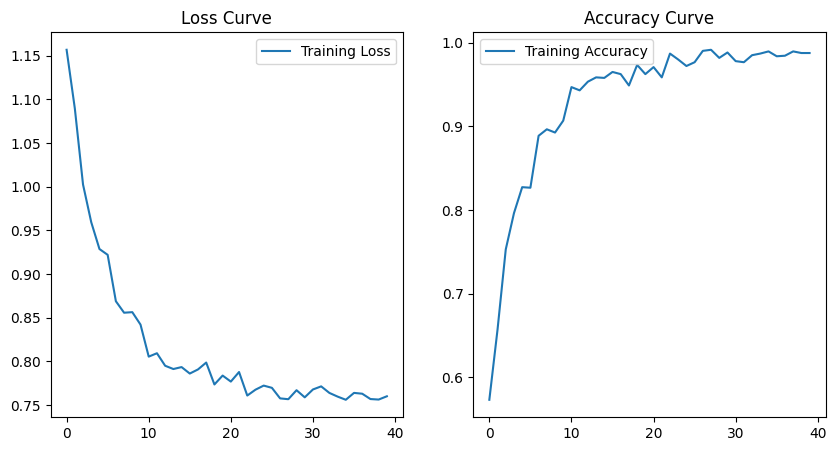

In [ ]:
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

criterion = nn.CrossEntropyLoss()
resnet18_model.to(device)
optimizer = optim.Adam(resnet18_model.parameters(), lr=0.0001)

train_losses, train_accuracies = [], []

for epoch in range(40):

    running_loss, running_corrects = 0.0, 0
    for i, data in enumerate(train_dataloader, 0):
        mri_images, clinical_data, labels = (
            data[0].to(device),
            data[1].to(device),
            data[2].to(device)
        )

        optimizer.zero_grad()
        outputs = resnet18_model(mri_images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * mri_images.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_dataloader.dataset)
    epoch_acc = running_corrects.double() / len(train_dataloader.dataset)

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc.item())


plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

In [ ]:
#torch.save(
#    mm_clf.state_dict(),
#    '/content/drive/Shareddrives/CSC550/Final_Flattened_Dataset/mm_clf.pth'
#)

torch.save(
    resnet18_model.state_dict(),
    '/content/drive/MyDrive/resnet18.pth'
)

In [ ]:
!pip install medcam

In [ ]:
from medcam import medcam

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
resnet18_model = ResNet18_3D(1, 4)
resnet18_model.to(device)

#state_dict = torch.load(
#    '/content/drive/Shareddrives/CSC550/Final_Flattened_Dataset/mm_clf.pth',
#    weights_only=True
#)

state_dict = torch.load(
    '/content/drive/MyDrive/resnet18.pth'
)
resnet18_model.load_state_dict(state_dict)

resnet18_model = medcam.inject(
    resnet18_model,
    output_dir="/content/drive/MyDrive/attention_maps",
    save_maps=True,
    backend='gcam',
    layer='layer1.0.conv1'
)

Final Test Accuracy: 0.7829


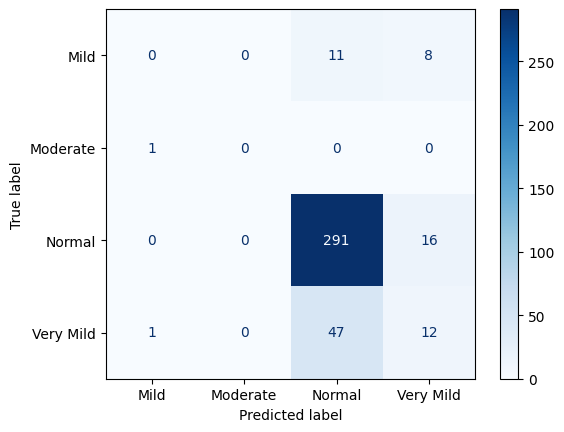

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

resnet18_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for i, data in enumerate(test_dataloader, 0):
        mri_images, clinical_data, labels = (
            data[0].to(device),
            data[1].to(device),
            data[2].to(device)
        )

        outputs = resnet18_model(mri_images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate test accuracy
test_acc = sum([p == l for p, l in zip(all_preds, all_labels)]) / len(all_labels)
print(f'Final Test Accuracy: {test_acc:.4f}')

# Generate and plot confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=master['Group'].astype('category').cat.categories)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [ ]:
print(resnet18_model.get_layers())

['norm', 'conv1', 'bn1', 'relu', 'maxpool', 'layer1.0.conv1', 'layer1.0.bn1', 'layer1.0.relu', 'layer1.0.conv2', 'layer1.0.bn2', 'layer1.0', 'layer1.1.conv1', 'layer1.1.bn1', 'layer1.1.relu', 'layer1.1.conv2', 'layer1.1.bn2', 'layer1.1', 'layer1', 'layer2.0.conv1', 'layer2.0.bn1', 'layer2.0.relu', 'layer2.0.conv2', 'layer2.0.bn2', 'layer2.0.downsample.0', 'layer2.0.downsample.1', 'layer2.0.downsample', 'layer2.0', 'layer2.1.conv1', 'layer2.1.bn1', 'layer2.1.relu', 'layer2.1.conv2', 'layer2.1.bn2', 'layer2.1', 'layer2', 'layer3.0.conv1', 'layer3.0.bn1', 'layer3.0.relu', 'layer3.0.conv2', 'layer3.0.bn2', 'layer3.0.downsample.0', 'layer3.0.downsample.1', 'layer3.0.downsample', 'layer3.0', 'layer3.1.conv1', 'layer3.1.bn1', 'layer3.1.relu', 'layer3.1.conv2', 'layer3.1.bn2', 'layer3.1', 'layer3', 'layer4.0.conv1', 'layer4.0.bn1', 'layer4.0.relu', 'layer4.0.conv2', 'layer4.0.bn2', 'layer4.0.downsample.0', 'layer4.0.downsample.1', 'layer4.0.downsample', 'layer4.0', 'layer4.1.conv1', 'layer4.1.

Final Test Accuracy: 0.7829


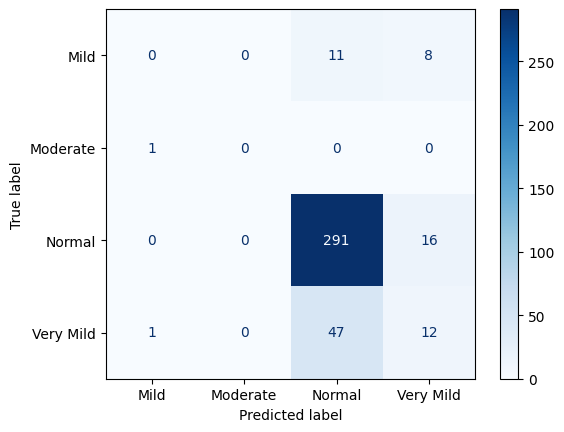

Saved 387 MRI/CAM NIfTI pairs in ./gradcam_3d


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import os
import torch
from medcam import medcam


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
resnet18_model = ResNet18_3D(1, 4)
resnet18_model.to(device)

#state_dict = torch.load(
#    '/content/drive/Shareddrives/CSC550/Final_Flattened_Dataset/mm_clf.pth',
#    weights_only=True
#)

state_dict = torch.load(
    '/content/drive/MyDrive/resnet18.pth'
)
resnet18_model.load_state_dict(state_dict)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import os
import torch
import torch.nn.functional as F
import nibabel as nib
from medcam import medcam

vis_model = medcam.inject(
    resnet18_model,
    backend="gcam",              # or "gcampp"
    layer="layer3.1.conv2",
    return_attention=True,
    save_maps=False,
    data_shape="default"         # output CAM in input spatial shape when supported
)

vis_model.eval()

os.makedirs("/content/drive/MyDrive/gradcam_3d", exist_ok=True)

all_preds, all_labels = [], []
saved_cases = 0


def normalize_volume(x):
    x = x.astype(np.float32)
    x = x - x.min()
    denom = x.max() - x.min()
    if denom > 0:
        x = x / denom
    return x


def prepare_cam(attn_tensor, target_shape):
    """
    Converts CAM to [D, H, W] and upsamples if needed.
    """
    if attn_tensor.ndim == 3:
        cam = attn_tensor.unsqueeze(0).unsqueeze(0)   # [1,1,d,h,w]
    elif attn_tensor.ndim == 4:
        cam = attn_tensor.unsqueeze(0)                # [1,1,d,h,w] if [1,d,h,w]
    elif attn_tensor.ndim == 5:
        cam = attn_tensor
    else:
        raise ValueError(f"Unexpected attention shape: {attn_tensor.shape}")

    if tuple(cam.shape[-3:]) != tuple(target_shape):
        cam = F.interpolate(
            cam.float(),
            size=target_shape,
            mode="trilinear",
            align_corners=False
        )

    cam = cam[0, 0].detach().cpu().numpy()
    cam = normalize_volume(cam)
    return cam


def save_nifti(array_3d, path, affine=None):
    if affine is None:
        affine = np.eye(4, dtype=np.float32)
    nii = nib.Nifti1Image(array_3d.astype(np.float32), affine)
    nib.save(nii, path)


for i, data in enumerate(test_dataloader, 0):
    mri_images, clinical_data, labels = (
        data[0].to(device),
        data[1].to(device),
        data[2].to(device)
    )

    # plain predictions
    outputs = vis_model.model_forward(mri_images)
    _, preds = torch.max(outputs, 1)

    # Grad-CAM for predicted classes
    outputs_cam, attn = vis_model(mri_images, label=preds)

    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

    if attn is None:
        continue

    imgs_cpu = mri_images.detach().cpu()
    attn_cpu = attn.detach().cpu()
    preds_np = preds.detach().cpu().numpy()
    labels_np = labels.detach().cpu().numpy()

    for b in range(imgs_cpu.shape[0]):
        volume = imgs_cpu[b, 0].numpy()  # [D,H,W]
        volume = normalize_volume(volume)
        target_shape = volume.shape

        if attn_cpu.ndim == 5:
            cam_b = attn_cpu[b:b+1]             # [1,1,d,h,w]
        elif attn_cpu.ndim == 4:
            cam_b = attn_cpu[b].unsqueeze(0)    # [1,d,h,w]
        else:
            continue

        cam = prepare_cam(cam_b, target_shape)

        case_id = f"sample_{saved_cases:04d}_true_{labels_np[b]}_pred_{preds_np[b]}"

        # Replace identity affine with your real MRI affine if available
        affine = np.eye(4, dtype=np.float32)

        save_nifti(volume, os.path.join("/content/drive/MyDrive/gradcam_3d", f"{case_id}_mri.nii.gz"), affine)
        save_nifti(cam,    os.path.join("/content/drive/MyDrive/gradcam_3d", f"{case_id}_cam.nii.gz"), affine)

        saved_cases += 1


# -------------------------------------------------
# Accuracy
# -------------------------------------------------
test_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"Final Test Accuracy: {test_acc:.4f}")

# -------------------------------------------------
# Confusion matrix
# -------------------------------------------------
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=master['Group'].astype('category').cat.categories
)
disp.plot(cmap=plt.cm.Blues)
plt.show()

print(f"Saved {saved_cases} MRI/CAM NIfTI pairs in ./gradcam_3d")

In [ ]:
print(master['Group'].astype('category').cat.categories)
print(master['Group'].value_counts())

Index(['Mild', 'Moderate', 'Normal', 'Very Mild'], dtype='object')
Group
Normal       1544
Very Mild     311
Mild          101
Moderate        7
Name: count, dtype: int64


In [ ]:
import gc

# 1. Move to CPU (Optional but ensures weights are off-device)
mm_clf.cpu()

# 2. Delete all references
del mm_clf
del optimizer  # Optimizers hold references to model parameters

# 4. Clear the PyTorch CUDA cache
torch.cuda.empty_cache()

# 3. Garbage collection
gc.collect()

824

              precision    recall  f1-score   support

        Mild       0.35      0.40      0.37        20
    Moderate       0.00      0.00      0.00         2
      Normal       0.90      0.89      0.90       309
   Very Mild       0.44      0.45      0.45        62

    accuracy                           0.79       393
   macro avg       0.42      0.44      0.43       393
weighted avg       0.79      0.79      0.79       393

Accuracy: 79.39%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


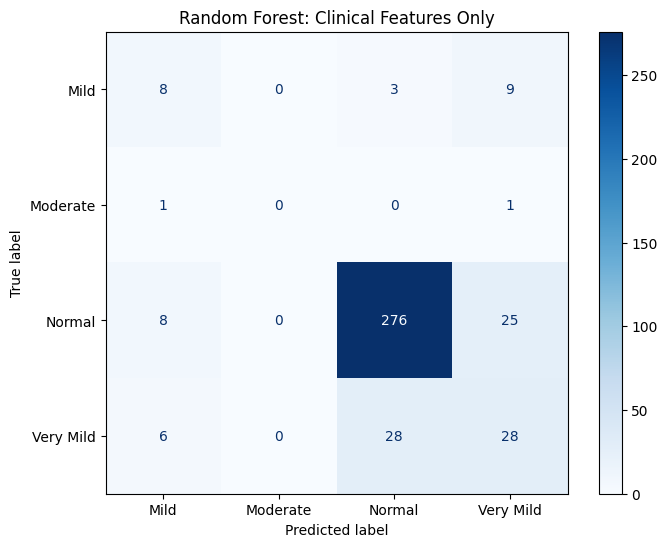

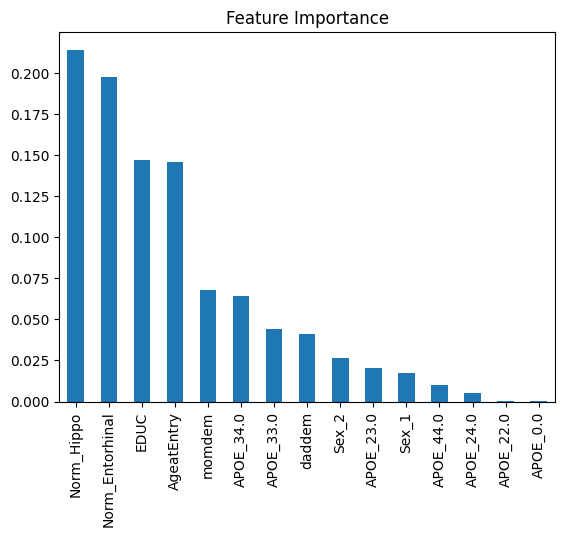

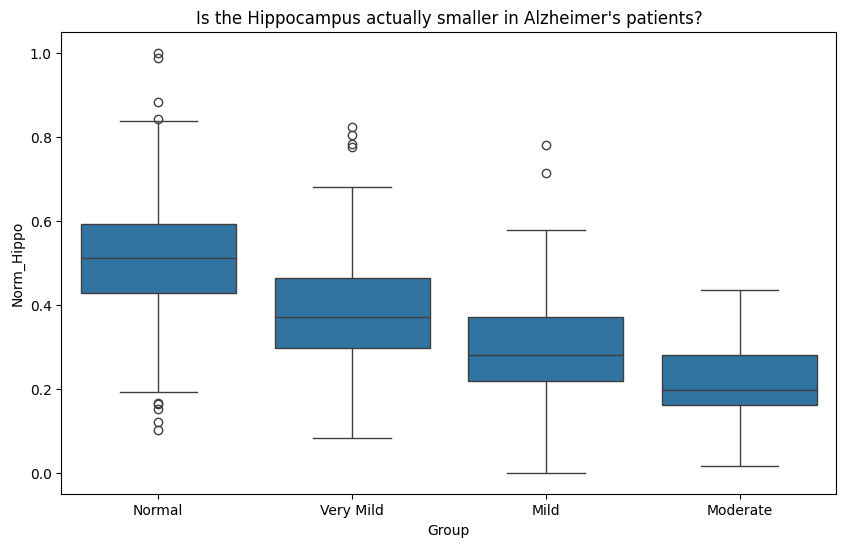

In [ ]:
# Flattened layer RF
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

df = pd.read_csv('Project_Final_Flattened_Dataset (3).csv')

features = [col for col in df.columns if col.startswith('APOE')] + \
 ['EDUC', 'momdem', 'daddem', 'AgeatEntry', 'Norm_Hippo', 'Norm_Entorhinal'] + \
  [col for col in df.columns if col.startswith('Sex')]


X = df[features]
y = df['Group']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#create more mild cases
smote = SMOTE(random_state=42, k_neighbors=2)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_resampled, y_resampled)

y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred))

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")


fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap='Blues', ax=ax)
plt.title("Random Forest: Clinical Features Only")
plt.show()

importance = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
importance.plot(kind='bar', title='Feature Importance')
plt.show()

#show hippocampus is smaller
import seaborn as sns
plt.figure(figsize=(10,6))
sns.boxplot(x='Group', y='Norm_Hippo', data=df)
plt.title("Norm Hippocampus Compared to Stage")
plt.show()

Mean Squared Error: 7.73


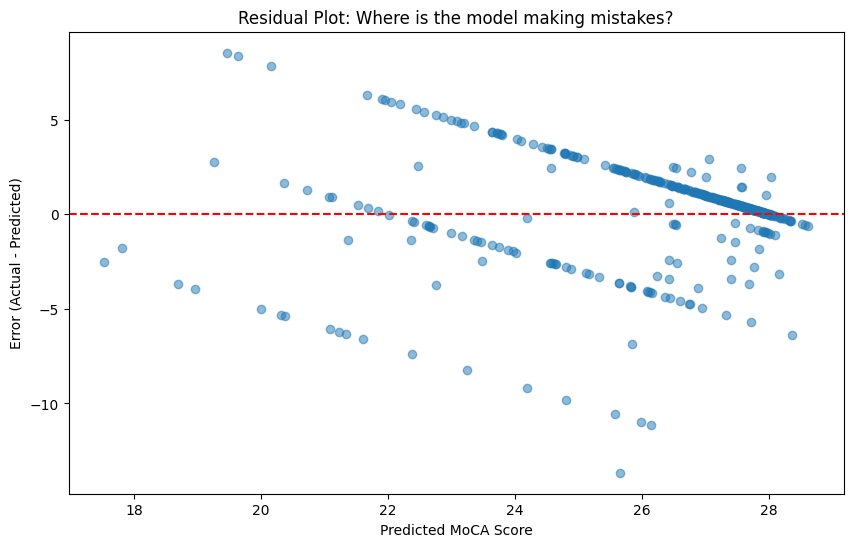

In [ ]:
#Regression

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

y_regression = df['moca']

X_reg = X[y_regression.notna()]
y_reg = y_regression[y_regression.notna()]

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
reg_model.fit(X_train, y_train)

y_pred = reg_model.predict(X_test)
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")


In [ ]:
!mkdir /content/drive/Shareddrives/CSC550/Project_Final_Flattened_Dataset/gradcam_3d

mkdir: cannot create directory ‘/content/drive/Shareddrives/CSC550/Project_Final_Flattened_Dataset/gradcam_3d’: File exists


In [ ]:
!rsync -av /content/drive/MyDrive/gradcam_3d/ /content/drive/Shareddrives/CSC550/Project_Final_Flattened_Dataset/gradcam_3d

sending incremental file list

sent 22,445 bytes  received 12 bytes  4,990.44 bytes/sec
total size is 14,447,131,840  speedup is 643,324.21
